<a href="https://colab.research.google.com/github/WestonWhiteUCD/PanCancer-MultiOmics/blob/main/PanCancer_MultiOmics_Transformer_Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PanCancer MultiOmics — Notebook 4: Transformer Autoencoder

## Purpose
Learn a non-linear compressed representation of the (8,314 × 1,009)
multi-omics fusion matrix using a transformer-based autoencoder in PyTorch.

The encoder compresses each patient's 1,009-dimensional molecular profile
into a 64-dimensional latent vector. The decoder reconstructs the original
input from that latent vector. The model is trained to minimize reconstruction
loss — no cancer labels used.

## Why a transformer autoencoder over PCA
PCA finds the best *linear* compression of the data. A transformer autoencoder
learns a *non-linear* compression via attention mechanisms and feed-forward
layers, capturing complex dependencies between genes and methylation sites
that linear projection cannot represent.

PCA baseline (NB3):    X → Vx = z        (linear, closed-form)
Transformer (NB4):     X → fθ(x) = z     (non-linear, learned)

## Architecture
Encoder: Linear projection → Transformer encoder layers → latent vector z
Decoder: Linear projection → Transformer decoder layers → reconstruction X̂

Loss: L = ||X - X̂||²    (mean squared error — reconstruction loss)

## Connection to Altos Labs
Foundation models for biology are large-scale autoencoders trained on
massive multi-omics datasets. The latent space captures disease mechanisms,
drug responses, and aging signatures. This notebook is a small-scale
prototype of that architecture.

## Note on scale
This implementation runs on a free Colab T4 GPU. A production version
would use distributed training (DDP/FSDP) across multiple nodes — the
next step in scaling this architecture.

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Confirm PyTorch version
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.11.0+cu128


## 0. Device Setup

In [2]:
# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Using device: {device}")

if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("  No GPU found — running on CPU")
    print("  Tip: Runtime → Change runtime type → T4 GPU in Colab")

Using device: cuda
  GPU: Tesla T4
  Memory: 15.6 GB


## 1. Load Data

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/My Drive/CompSci Proj')

aligned_path = 'aligned/'

# Load fusion matrix — output of Notebook 2
fusion_matrix = np.load(aligned_path + 'fusion_matrix.npy')

# Load labels — withheld from training, used post-hoc only
labels = pd.read_csv(aligned_path + 'labels.csv', index_col=0).squeeze()

print("Loaded:")
print(f"  Fusion matrix: {fusion_matrix.shape}")
print(f"  Dtype:         {fusion_matrix.dtype}")
print(f"  Labels:        {labels.shape}")

# Sanity checks
assert fusion_matrix.shape == (8314, 1009), "Unexpected fusion matrix shape!"
assert not np.isnan(fusion_matrix).any(),   "NaN values detected!"
assert len(labels) == 8314,                 "Label count mismatch!"

print("\nAll assertions passed — ready for PyTorch Dataset.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded:
  Fusion matrix: (8314, 1009)
  Dtype:         float64
  Labels:        (8314,)

All assertions passed — ready for PyTorch Dataset.


## 2. PyTorch Dataset & DataLoader

In [5]:
class MultiOmicsDataset(Dataset):
    """
    PyTorch Dataset wrapping the multi-omics fusion matrix.
    Converts numpy float64 → torch float32 at access time.
    Labels are stored separately — never passed to the autoencoder.
    """
    def __init__(self, data: np.ndarray):
        # Convert float64 → float32 to halve GPU memory footprint
        self.data = torch.tensor(data, dtype=torch.float32)

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        return self.data[idx]

# Instantiate dataset
dataset = MultiOmicsDataset(fusion_matrix)

print(f"Dataset size:   {len(dataset)} samples")
print(f"Sample shape:   {dataset[0].shape}")
print(f"Sample dtype:   {dataset[0].dtype}")
print(f"Memory (float32): {dataset.data.element_size() * dataset.data.nelement() / 1e6:.1f} MB")
print(f"Memory (float64 would be): {dataset.data.element_size() * 2 * dataset.data.nelement() / 1e6:.1f} MB")

Dataset size:   8314 samples
Sample shape:   torch.Size([1009])
Sample dtype:   torch.float32
Memory (float32): 33.6 MB
Memory (float64 would be): 67.1 MB


In [6]:
BATCH_SIZE = 64

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=(device.type == 'cuda')
)

print(f"Batch size:      {BATCH_SIZE}")
print(f"Total batches:   {len(dataloader)}")
print(f"Samples/epoch:   {len(dataloader) * BATCH_SIZE}")
print(f"pin_memory:      {device.type == 'cuda'}")

# Inspect one batch
sample_batch = next(iter(dataloader))
print(f"\nSample batch shape: {sample_batch.shape}")
print(f"  → {BATCH_SIZE} patients × 1009 features")

Batch size:      64
Total batches:   130
Samples/epoch:   8320
pin_memory:      True

Sample batch shape: torch.Size([64, 1009])
  → 64 patients × 1009 features


## 2. Model Architecture — Multimodal Transformer Autoencoder

### Design choice: modality-level tokenization
Each modality is compressed into a single d_model-dimensional token:

    mRNA     (500 features) → Linear → token₀ ∈ ℝ^d_model
    Methy    (500 features) → Linear → token₁ ∈ ℝ^d_model
    Clinical   (9 features) → Linear → token₂ ∈ ℝ^d_model

The transformer encoder attends across these 3 tokens — learning which
modalities are most informative for each other. This is biologically
meaningful: DNA methylation mechanistically silences genes, so the
methylation and mRNA tokens should have high cross-attention weights.

### Information flow
    Input x ∈ ℝ^1009
      ↓  split into 3 modalities
      ↓  project each to d_model → (batch, 3, d_model)
      ↓  Transformer encoder (cross-modal self-attention)
      ↓  flatten → (batch, 3 × d_model)
      ↓  Linear → latent z ∈ ℝ^64
      ↓  Linear → (batch, 3 × d_model)
      ↓  reshape → (batch, 3, d_model)
      ↓  Transformer decoder
      ↓  project each token back to modality dimension
      ↓  concatenate → X̂ ∈ ℝ^1009

### Loss
    L = ||X - X̂||²    (mean squared error — reconstruction loss)

In [7]:
# ── Hyperparameters ────────────────────────────────────────────────────────
MRNA_DIM     = 500
METHY_DIM    = 500
CLINICAL_DIM = 9
D_MODEL      = 128   # dimension of each modality token
NHEAD        = 4     # attention heads (D_MODEL must be divisible by NHEAD)
NUM_LAYERS   = 2     # transformer layers in encoder and decoder
LATENT_DIM   = 64    # compressed latent space dimension
DROPOUT      = 0.1

class TransformerAutoencoder(nn.Module):
    """
    Multimodal transformer autoencoder for multi-omics data.

    Each modality (mRNA, methylation, clinical) is projected to a
    d_model-dimensional token. The transformer encoder learns cross-modal
    attention weights across the 3 tokens. The latent vector z is a
    64-dimensional compressed representation of the full molecular profile.

    Architecture directly analogous to multimodal foundation models —
    the difference is scale and training data size.
    """

    def __init__(self, mrna_dim=MRNA_DIM, methy_dim=METHY_DIM,
                 clinical_dim=CLINICAL_DIM, d_model=D_MODEL,
                 nhead=NHEAD, num_layers=NUM_LAYERS,
                 latent_dim=LATENT_DIM, dropout=DROPOUT):
        super().__init__()

        self.mrna_dim     = mrna_dim
        self.methy_dim    = methy_dim
        self.clinical_dim = clinical_dim
        self.d_model      = d_model

        # ── Encoder: modality projections ─────────────────────────────
        # Each modality compressed to one d_model-dimensional token
        self.mrna_proj     = nn.Linear(mrna_dim, d_model)
        self.methy_proj    = nn.Linear(methy_dim, d_model)
        self.clinical_proj = nn.Linear(clinical_dim, d_model)

        # ── Encoder: cross-modal transformer ──────────────────────────
        # Self-attention across 3 modality tokens (3×3 attention matrix)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True       # (batch, seq, d_model) convention
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers
        )

        # Flatten 3 tokens and compress to latent vector
        self.latent_proj = nn.Linear(d_model * 3, latent_dim)

        # ── Decoder: expand latent ─────────────────────────────────────
        self.latent_expand = nn.Linear(latent_dim, d_model * 3)

        # Cross-modal transformer in decoder
        decoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_decoder = nn.TransformerEncoder(
            decoder_layer, num_layers=num_layers
        )

        # ── Decoder: modality reconstructions ─────────────────────────
        # Each token projected back to its original modality dimension
        self.mrna_recon     = nn.Linear(d_model, mrna_dim)
        self.methy_recon    = nn.Linear(d_model, methy_dim)
        self.clinical_recon = nn.Linear(d_model, clinical_dim)

    def encode(self, x):
        # Split fusion matrix back into modalities
        mrna     = x[:, :self.mrna_dim]
        methy    = x[:, self.mrna_dim:self.mrna_dim + self.methy_dim]
        clinical = x[:, self.mrna_dim + self.methy_dim:]

        # Project each modality to d_model and add sequence dimension
        t_mrna     = self.mrna_proj(mrna).unsqueeze(1)        # (batch, 1, d_model)
        t_methy    = self.methy_proj(methy).unsqueeze(1)      # (batch, 1, d_model)
        t_clinical = self.clinical_proj(clinical).unsqueeze(1)# (batch, 1, d_model)

        # Stack into sequence of 3 modality tokens
        tokens = torch.cat([t_mrna, t_methy, t_clinical], dim=1)  # (batch, 3, d_model)

        # Cross-modal self-attention
        tokens = self.transformer_encoder(tokens)              # (batch, 3, d_model)

        # Flatten and project to latent space
        z = self.latent_proj(tokens.flatten(start_dim=1))     # (batch, latent_dim)
        return z

    def decode(self, z):
        # Expand latent back to 3-token sequence
        tokens = self.latent_expand(z).view(-1, 3, self.d_model)  # (batch, 3, d_model)

        # Cross-modal attention in decoder
        tokens = self.transformer_decoder(tokens)              # (batch, 3, d_model)

        # Reconstruct each modality from its token
        mrna_hat     = self.mrna_recon(tokens[:, 0, :])       # (batch, 500)
        methy_hat    = self.methy_recon(tokens[:, 1, :])      # (batch, 500)
        clinical_hat = self.clinical_recon(tokens[:, 2, :])   # (batch, 9)

        # Concatenate into full fusion matrix reconstruction
        return torch.cat([mrna_hat, methy_hat, clinical_hat], dim=1)  # (batch, 1009)

    def forward(self, x):
        z    = self.encode(x)
        x_hat = self.decode(z)
        return x_hat, z

## 3. Training Setup

In [8]:
LEARNING_RATE = 1e-3

# ── Model ─────────────────────────────────────────────────────────────────
model = TransformerAutoencoder().to(device)

# ── Loss function ──────────────────────────────────────────────────────────
# Mean Squared Error — measures reconstruction quality
# L = (1/n) Σ ||x - x̂||²
criterion = nn.MSELoss()

# ── Optimizer ─────────────────────────────────────────────────────────────
# Adam — adaptive learning rate, standard choice for transformers
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# ── Parameter count ───────────────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model architecture:")
print(f"  d_model:      {D_MODEL}")
print(f"  nhead:        {NHEAD}")
print(f"  num_layers:   {NUM_LAYERS}")
print(f"  latent_dim:   {LATENT_DIM}")
print(f"\nParameters:")
print(f"  Total:        {total_params:,}")
print(f"  Trainable:    {trainable_params:,}")
print(f"\nOptimizer:    Adam (lr={LEARNING_RATE})")
print(f"Loss:         MSELoss")
print(f"Device:       {device}")

Model architecture:
  d_model:      128
  nhead:        4
  num_layers:   2
  latent_dim:   64

Parameters:
  Total:        1,102,385
  Trainable:    1,102,385

Optimizer:    Adam (lr=0.001)
Loss:         MSELoss
Device:       cuda


## 3. Training Loop

### The four steps of every gradient update
For each mini-batch, PyTorch performs four operations in order:

1. optimizer.zero_grad()   — clear gradients from previous batch
2. x_hat, z = model(x)    — forward pass: compute prediction
3. loss.backward()         — backward pass: compute gradients
4. optimizer.step()        — update weights using gradients

These four steps repeat for every batch in every epoch.

In [9]:
N_EPOCHS = 50

# Track loss per epoch
train_losses = []

print(f"Training for {N_EPOCHS} epochs...")
print(f"  Batches per epoch: {len(dataloader)}")
print(f"  Device: {device}\n")

for epoch in range(N_EPOCHS):

    # ── Set model to training mode ─────────────────────────────────────
    # Enables dropout and batch norm (if any)
    model.train()

    epoch_loss = 0.0

    for batch in dataloader:

        # ── Move batch to GPU ──────────────────────────────────────────
        x = batch.to(device)                   # (64, 1009) on GPU

        # ── Step 1: Clear gradients ────────────────────────────────────
        # Gradients accumulate by default — must zero before each batch
        optimizer.zero_grad()

        # ── Step 2: Forward pass ───────────────────────────────────────
        # x_hat = reconstruction, z = latent vector
        x_hat, z = model(x)                    # both on GPU

        # ── Step 3: Compute loss + backward pass ───────────────────────
        # L = (1/n) Σ ||x - x_hat||²
        loss = criterion(x_hat, x)
        loss.backward()                         # compute ∂L/∂θ for all θ

        # ── Step 4: Update weights ─────────────────────────────────────
        optimizer.step()                        # θ ← θ - η * ∂L/∂θ

        epoch_loss += loss.item()

    # Average loss over all batches in this epoch
    avg_loss = epoch_loss / len(dataloader)
    train_losses.append(avg_loss)

    # Print every 5 epochs
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch [{epoch+1:3d}/{N_EPOCHS}]  Loss: {avg_loss:.6f}")

print(f"\nTraining complete.")
print(f"  Initial loss: {train_losses[0]:.6f}")
print(f"  Final loss:   {train_losses[-1]:.6f}")
print(f"  Reduction:    {(1 - train_losses[-1]/train_losses[0])*100:.1f}%")

Training for 50 epochs...
  Batches per epoch: 130
  Device: cuda

  Epoch [  5/50]  Loss: 0.300106
  Epoch [ 10/50]  Loss: 0.270157
  Epoch [ 15/50]  Loss: 0.257994
  Epoch [ 20/50]  Loss: 0.250812
  Epoch [ 25/50]  Loss: 0.246379
  Epoch [ 30/50]  Loss: 0.243254
  Epoch [ 35/50]  Loss: 0.240973
  Epoch [ 40/50]  Loss: 0.239176
  Epoch [ 45/50]  Loss: 0.237778
  Epoch [ 50/50]  Loss: 0.236519

Training complete.
  Initial loss: 0.542529
  Final loss:   0.236519
  Reduction:    56.4%


## 3.1 Training Loss Curve

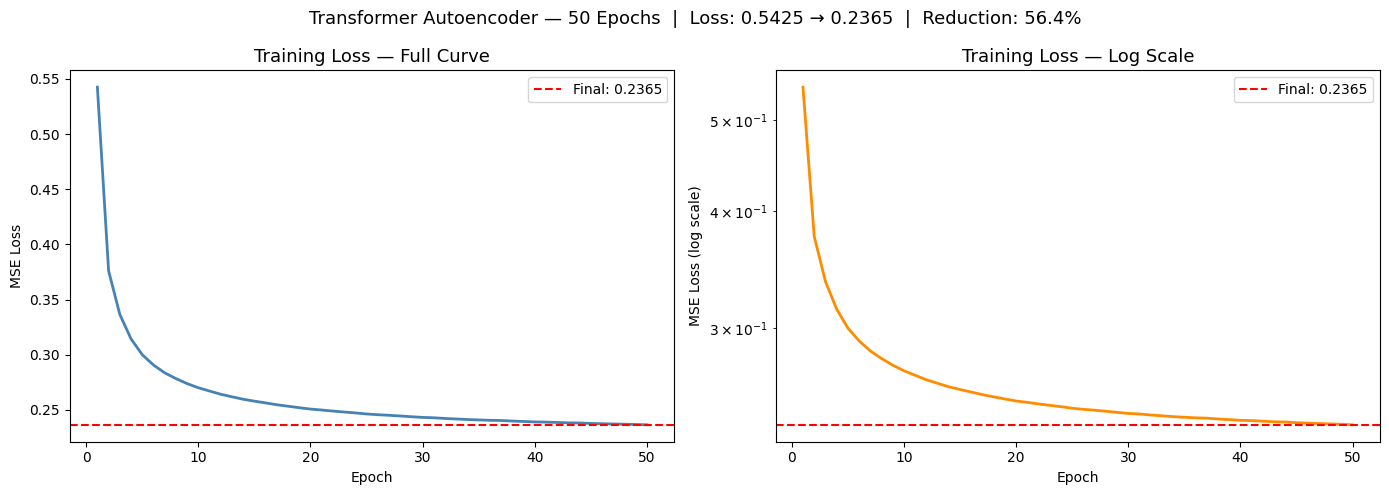

Loss reduction per 5-epoch interval:
  Epoch   1→  6:  0.542529 → 0.290766  (drop: 0.251763)
  Epoch   6→ 11:  0.290766 → 0.267165  (drop: 0.023602)
  Epoch  11→ 16:  0.267165 → 0.256394  (drop: 0.010770)
  Epoch  16→ 21:  0.256394 → 0.249954  (drop: 0.006440)
  Epoch  21→ 26:  0.249954 → 0.245710  (drop: 0.004245)
  Epoch  26→ 31:  0.245710 → 0.242911  (drop: 0.002799)
  Epoch  31→ 36:  0.242911 → 0.240640  (drop: 0.002271)
  Epoch  36→ 41:  0.240640 → 0.238997  (drop: 0.001643)
  Epoch  41→ 46:  0.238997 → 0.237531  (drop: 0.001466)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Full loss curve ────────────────────────────────────────────────────────
axes[0].plot(range(1, N_EPOCHS + 1), train_losses,
             linewidth=2, color='steelblue')
axes[0].set_title('Training Loss — Full Curve', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].axhline(y=train_losses[-1], color='red',
                linestyle='--', label=f'Final: {train_losses[-1]:.4f}')
axes[0].legend()

# ── Log scale — reveals convergence behavior ───────────────────────────────
axes[1].plot(range(1, N_EPOCHS + 1), train_losses,
             linewidth=2, color='darkorange')
axes[1].set_yscale('log')
axes[1].set_title('Training Loss — Log Scale', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss (log scale)')
axes[1].axhline(y=train_losses[-1], color='red',
                linestyle='--', label=f'Final: {train_losses[-1]:.4f}')
axes[1].legend()

plt.suptitle(
    f'Transformer Autoencoder — 50 Epochs  |  '
    f'Loss: {train_losses[0]:.4f} → {train_losses[-1]:.4f}  |  '
    f'Reduction: {(1 - train_losses[-1]/train_losses[0])*100:.1f}%',
    fontsize=13
)
plt.tight_layout()
plt.show()

# ── Per-interval analysis ──────────────────────────────────────────────────
print("Loss reduction per 5-epoch interval:")
for i in range(0, N_EPOCHS - 5, 5):
    drop = train_losses[i] - train_losses[i + 5]
    print(f"  Epoch {i+1:3d}→{i+6:3d}:  "
          f"{train_losses[i]:.6f} → {train_losses[i+5]:.6f}  "
          f"(drop: {drop:.6f})")

## 4. Extract Latent Representations

In [11]:
# ── Set model to evaluation mode ──────────────────────────────────────────
# Disables dropout — every patient gets a deterministic encoding
model.eval()

latent_vectors = []

# ── No gradient computation needed for inference ──────────────────────────
# torch.no_grad() disables the computation graph — faster and uses
# significantly less GPU memory
with torch.no_grad():
    for batch in dataloader:
        x   = batch.to(device)      # (64, 1009) on GPU
        z   = model.encode(x)       # (64, 64) latent vectors
        latent_vectors.append(z.cpu().numpy())

# Concatenate all batches into one array
Z_transformer = np.concatenate(latent_vectors, axis=0)

print(f"Latent representation extracted:")
print(f"  Input:  {fusion_matrix.shape}  (8314 patients × 1009 features)")
print(f"  Output: {Z_transformer.shape}  (8314 patients × 64 latent dims)")
print(f"  Compression ratio: {fusion_matrix.shape[1] / Z_transformer.shape[1]:.1f}x")
print(f"\nLatent vector statistics:")
print(f"  Mean: {Z_transformer.mean():.4f}")
print(f"  Std:  {Z_transformer.std():.4f}")
print(f"  Min:  {Z_transformer.min():.4f}")
print(f"  Max:  {Z_transformer.max():.4f}")

Latent representation extracted:
  Input:  (8314, 1009)  (8314 patients × 1009 features)
  Output: (8314, 64)  (8314 patients × 64 latent dims)
  Compression ratio: 15.8x

Latent vector statistics:
  Mean: 0.0240
  Std:  1.6688
  Min:  -8.3273
  Max:  7.6158


## 5. Save Outputs

In [13]:
aligned_path = 'aligned/'

# ── Save 1: Transformer latent vectors (for NB5 comparison) ──────────────
np.save(aligned_path + 'Z_transformer.npy', Z_transformer)
print(f"Saved Z_transformer.npy:     {Z_transformer.shape}")

# ── Save 2: Training loss curve (for NB5 reporting) ──────────────────────
np.save(aligned_path + 'train_losses.npy', np.array(train_losses))
print(f"Saved train_losses.npy:      {len(train_losses)} epochs")

# ── Save 3: Model weights (for reproducibility) ───────────────────────────
torch.save(model.state_dict(),
           '/content/drive/My Drive/CompSci Proj/transformer_weights.pt')
print(f"Saved transformer_weights.pt")

# ── Final summary ─────────────────────────────────────────────────────────
print(f"\n── Notebook 4 complete ──────────────────────────────────────────")
print(f"  Architecture:      Transformer Autoencoder")
print(f"  Input dim:         {fusion_matrix.shape[1]}")
print(f"  Latent dim:        {Z_transformer.shape[1]}")
print(f"  Compression:       {fusion_matrix.shape[1]/Z_transformer.shape[1]:.1f}x")
print(f"  Training epochs:   {N_EPOCHS}")
print(f"  Final MSE loss:    {train_losses[-1]:.6f}")
print(f"  Loss reduction:    {(1 - train_losses[-1]/train_losses[0])*100:.1f}%")
print(f"  Latent mean:       {Z_transformer.mean():.4f}")
print(f"  Latent std:        {Z_transformer.std():.4f}")
print(f"\nComparison available in Notebook 5:")
print(f"  PCA baseline:      Z_pca.npy         {(8314, 154)}")
print(f"  Transformer:       Z_transformer.npy  {Z_transformer.shape}")

Saved Z_transformer.npy:     (8314, 64)
Saved train_losses.npy:      50 epochs
Saved transformer_weights.pt

── Notebook 4 complete ──────────────────────────────────────────
  Architecture:      Transformer Autoencoder
  Input dim:         1009
  Latent dim:        64
  Compression:       15.8x
  Training epochs:   50
  Final MSE loss:    0.236519
  Loss reduction:    56.4%
  Latent mean:       0.0240
  Latent std:        1.6688

Comparison available in Notebook 5:
  PCA baseline:      Z_pca.npy         (8314, 154)
  Transformer:       Z_transformer.npy  (8314, 64)
